# 🎬 Workshopstart — Lea, signalet og baseline

**Lea er i ferd med å forsvinne.**

Hun er en av StreamNords mest aktive brukere. Hun elsker nordisk indie-drama
og mørkere katalogtitler — men får de samme blockbusterne som alle andre.
Produktteamet trenger et svar til møtet i morgen: **hva bør vi bygge?**

Du er den nye ML-ingeniøren hos StreamNord — en norsk strømmetjeneste
med ~5 000 aktive brukere og ~10 000 filmer i katalogen.
Denne notatboken gjør fire ting: etablerer caset, forklarer signalet,
setter opp evalueringen og måler den sterkeste enkle baselinen.

---

### Konsolidert workshopløp

| Notebook | Rolle i workshopen |
|---|---|
| `00_velkommen` | Case, signal, metrikker og baseline |
| `01_content_based` | Første personaliserte modell |
| `02_collaborative_filtering` | CF og matrix factorization |
| `03_hybrid_systems` | Hybrider, kontekst og fairness |
| `04_ship_decision` | Sluttanbefaling og produksjonsvalg |

Tyngre eller mer spesialisert stoff ligger som **valgfri appendix** inne i de relevante notebookene.

## 1. Verifiser miljøet

In [1]:
import sys
print(f'Python {sys.version}')

import pandas as pd
import numpy as np
import scipy
import sklearn
import matplotlib

print(f'pandas {pd.__version__}')
print(f'numpy {np.__version__}')
print(f'scipy {scipy.__version__}')
print(f'scikit-learn {sklearn.__version__}')
print(f'matplotlib {matplotlib.__version__}')

try:
    import implicit
    print(f'implicit {implicit.__version__}')
except ImportError:
    print('implicit not installed')

try:
    import faiss
    print('faiss OK')
except ImportError:
    print('faiss-cpu not installed')

print('\nAlle importer OK')

Python 3.11.14 (main, Oct 14 2025, 21:33:50) [Clang 20.1.4 ]
pandas 3.0.1
numpy 2.4.2
scipy 1.17.1
scikit-learn 1.8.0
matplotlib 3.10.8
implicit 0.7.2
faiss OK

Alle importer OK


/Users/kenanmahic/Projects/recommender-systems-ws/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Last ned og klargjør data

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from data.sample_ml25m import sample_and_save, OUT_DIR

if (OUT_DIR / 'interactions.parquet').exists():
    print(f'Data finnes allerede i {OUT_DIR}')
else:
    sample_and_save()

Data finnes allerede i /Users/kenanmahic/Projects/recommender-systems-ws/data/ml-25m-sample


## 3. Last inn interaksjoner og metadata

In [3]:
from src.data import load_interactions, load_item_metadata, GENRE_COLS

interactions = load_interactions()
items = load_item_metadata()

n_users = interactions.user_id.nunique()
n_items = interactions.item_id.nunique()
n_interactions = len(interactions)
sparsity = 1 - n_interactions / (n_users * n_items)

print(f'Interaksjoner: {n_interactions:,} rader')
print(f'Brukere:       {n_users:,}')
print(f'Filmer:        {n_items:,}')
print(f'Sparsitet:     {sparsity:.2%}')

interactions.head()

Interaksjoner: 3,358,357 rader
Brukere:       15,000
Filmer:        12,169
Sparsitet:     98.16%


,user_id,item_id,timestamp
0,0,273,1147880044
1,0,283,1147868817
2,0,284,1147868828
3,0,599,1147878820
4,0,759,1147868510


## 4. 📊 Møt Lea

Lea (bruker 451) er en av StreamNords mest trofaste brukere — men de siste
ukene har hun nesten sluttet å klikke. La oss se hva hun faktisk har sett.

In [4]:
LEA_ID = 451
lea_items = interactions[interactions.user_id == LEA_ID].merge(items, on='item_id')
print(f'Lea har sett {len(lea_items)} filmer. De siste 10:')
lea_items.tail(10)[['title'] + GENRE_COLS[:6]]

Lea har sett 118 filmer. De siste 10:


,title,Drama,Action,Adventure,Animation,Children,Comedy
108,1984 (Nineteen Eighty-Four) (1984),1,0,0,0,0,0
109,Return to Paradise (1998),1,0,0,0,0,0
110,Broadcast News (1987),1,0,0,0,0,1
111,Working Girl (1988),1,0,0,0,0,1
112,Indecent Proposal (1993),1,0,0,0,0,0
113,"Player, The (1992)",1,0,0,0,0,1
114,Edward Scissorhands (1990),1,0,0,0,0,0
115,Sid and Nancy (1986),1,0,0,0,0,0
116,Mass Appeal (1984),1,0,0,0,0,0
117,"Thin Red Line, The (1998)",1,1,0,0,0,0


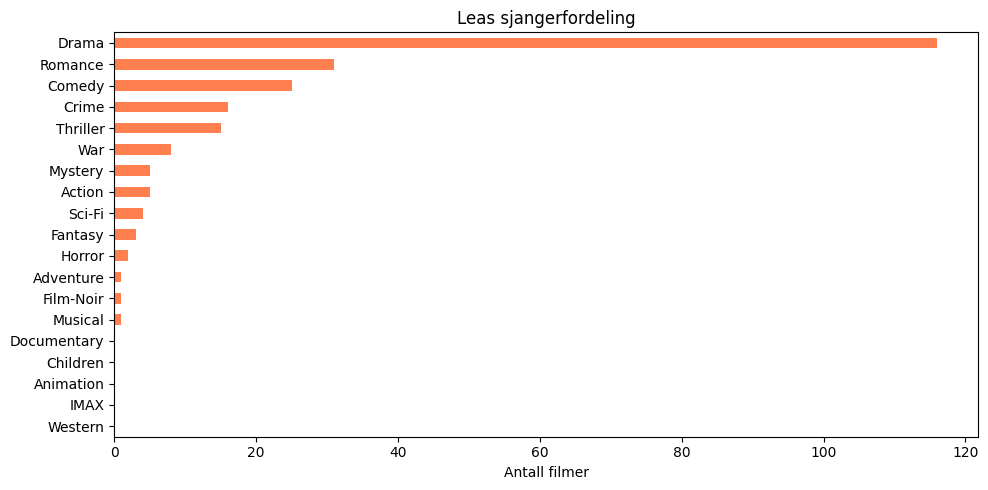

In [5]:
import matplotlib.pyplot as plt

lea_genre_dist = lea_items[GENRE_COLS].sum().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
lea_genre_dist.plot.barh(ax=ax, color='coral')
ax.set_xlabel('Antall filmer')
ax.set_title('Leas sjangerfordeling')
plt.tight_layout()
plt.show()

## 🏋️ Før vi kjører noen modell

Skriv ned tre gjetninger før du ser resultatene:

1. Hva slags filmer tror du Lea vil ha anbefalt?
2. Hva tror du popularitetslisten vil inneholde?
3. Tror du popularitet vil gi Lea en god opplevelse? Hvorfor / hvorfor ikke?

In [6]:
# DINE GJETNINGER (skriv i kommentarene)
#
# 1. Lea vil sannsynligvis like: 
# 2. Popularitetslisten inneholder trolig: 
# 3. Popularitet fungerer / fungerer ikke for Lea fordi: 
#
# Kom tilbake hit etter at popularitetsbaselinen har kjørt.

## 5. Hvilket signal har vi?

### Eksplisitt vs implisitt feedback

| Type | Eksempler | Fordel | Problem |
|---|---|---|---|
| **Eksplisitt** | Stjerner, likes, tommel opp | Tydelig preferanse | Sjelden i virkelige produkter |
| **Implisitt** | Klikk, visning, kjøp, avspilling | Finnes i store mengder | Manglende data er tvetydig |

StreamNord-dataene våre er hovedsakelig **implisitte**. Tenk på det slik:
en rating er en melding — et klikk er bare et blikk. Vi har bare blikkene.

Vi vet at Lea så noe, men ikke sikkert om hun aktivt likte det.
Derfor betyr manglende interaksjon ikke automatisk avvisning.

## 6. Evalueringsoppsett

Vi løser et **topp-N-rangeringsproblem**, ikke rating-prediksjon.

### Metrikker

- **Recall@K**: fant vi relevant innhold i topp-K?
- **NDCG@K**: lå det høyt nok i listen?
- **MAP@K**: hvor tidlig dukker treffet opp?

I tillegg bruker vi en leave-one-out-splitt: siste interaksjon per bruker
holdes tilbake som test.

In [7]:
from src.split import leave_one_out_split, build_sparse_matrix
from src.metrics import recall_at_k, ndcg_at_k, map_at_k

train_df, test_df = leave_one_out_split(interactions)
n_users = interactions.user_id.max() + 1
n_items = interactions.item_id.max() + 1
train_matrix = build_sparse_matrix(train_df, n_users, n_items)
user_ids = test_df['user_id'].values
test_items = test_df['item_id'].values
K = 10

print(f'Trening: {len(train_df):,} interaksjoner')
print(f'Test:    {len(test_df):,} interaksjoner (1 per bruker)')
print(f'Matrise: {train_matrix.shape}, nnz={train_matrix.nnz:,}')

Trening: 3,343,357 interaksjoner
Test:    15,000 interaksjoner (1 per bruker)
Matrise: (15000, 12169), nnz=3,343,357


## 7. Den late anbefalingen

"Gi alle det samme." Popularitet er den enkleste strategien —
og overraskende vanskelig å slå. La oss se hva den gjør med Lea.

In [8]:
item_counts = np.asarray(train_matrix.sum(axis=0)).flatten()
global_ranking = np.argsort(-item_counts)

def recommend_popular(train_matrix, user_ids, k=10):
    recommendations = np.zeros((len(user_ids), k), dtype=np.int32)
    for row_index, user_id in enumerate(user_ids):
        seen = set(train_matrix[user_id].indices)
        unseen_popular = [item_id for item_id in global_ranking if item_id not in seen][:k]
        recommendations[row_index] = unseen_popular
    return recommendations

recs_pop = recommend_popular(train_matrix, user_ids, k=K)
recall_value = recall_at_k(recs_pop, test_items, K)
ndcg_value = ndcg_at_k(recs_pop, test_items, K)
map_value = map_at_k(recs_pop, test_items, K)

print(f'Popularitet: Recall@{K}={recall_value:.4f}  NDCG@{K}={ndcg_value:.4f}  MAP@{K}={map_value:.4f}')

Popularitet: Recall@10=0.0326  NDCG@10=0.0161  MAP@10=0.0112


In [9]:
lea_idx = np.where(user_ids == LEA_ID)[0][0]
overlap_0_100 = len(set(recs_pop[0]) & set(recs_pop[100])) / K
overlap_0_lea = len(set(recs_pop[0]) & set(recs_pop[lea_idx])) / K
print(f'Overlapp bruker 0 vs bruker 100: {overlap_0_100:.0%}')
print(f'Overlapp bruker 0 vs Lea (451):  {overlap_0_lea:.0%}')

lea_titles = items.set_index('item_id').loc[recs_pop[lea_idx]]
print('\nPopularitetsanbefalinger til Lea:')
for rank, (_, row) in enumerate(lea_titles.iterrows(), 1):
    genres = [genre for genre in GENRE_COLS if row.get(genre, 0) == 1]
    genre_label = ', '.join(genres[:3])
    print(f'  {rank:>2}. {row["title"]}  [{genre_label}]')

Overlapp bruker 0 vs bruker 100: 90%
Overlapp bruker 0 vs Lea (451):  80%

Popularitetsanbefalinger til Lea:
   1. Forrest Gump (1994)  [Drama, Comedy, Romance]
   2. Matrix, The (1999)  [Action, Sci-Fi, Thriller]
   3. Star Wars: Episode IV - A New Hope (1977)  [Action, Adventure, Sci-Fi]
   4. Jurassic Park (1993)  [Action, Adventure, Sci-Fi]
   5. Star Wars: Episode V - The Empire Strikes Back (1980)  [Action, Adventure, Sci-Fi]
   6. Braveheart (1995)  [Drama, Action, War]
   7. Fight Club (1999)  [Drama, Action, Crime]
   8. Terminator 2: Judgment Day (1991)  [Action, Sci-Fi]
   9. Schindler's List (1993)  [Drama, War]
  10. Lord of the Rings: The Fellowship of the Ring, The (2001)  [Adventure, Fantasy]


Lea elsker nordisk indie-drama. Popularitetslisten gir henne mainstream.
**Noe stemmer ikke.**

> ✅ **Sjekk gjetningene dine**
>
> Gå tilbake til gjetningene du skrev ned. Stemte de?
> Hva overrasket deg med popularitetslisten til Lea?

## Valgfri appendix — tilfeldig baseline

Denne delen kan brukes hvis dere vil vise en helt naiv nedre grense.
I kjerneflyten kan den hoppes over.

In [10]:
def recommend_random(train_matrix, user_ids, k=10, seed=42):
    rng = np.random.default_rng(seed)
    all_items = np.arange(train_matrix.shape[1])
    recommendations = np.zeros((len(user_ids), k), dtype=np.int32)
    for row_index, user_id in enumerate(user_ids):
        unseen = np.setdiff1d(all_items, train_matrix[user_id].indices)
        recommendations[row_index] = rng.choice(unseen, size=k, replace=False)
    return recommendations

recs_rand = recommend_random(train_matrix, user_ids, k=K)
print(f"{'Modell':<14} {'Recall@10':>10} {'NDCG@10':>10} {'MAP@10':>10}")
print('-' * 48)
for name, recs in [('Popularitet', recs_pop), ('Tilfeldig', recs_rand)]:
    recall_value = recall_at_k(recs, test_items, K)
    ndcg_value = ndcg_at_k(recs, test_items, K)
    map_value = map_at_k(recs, test_items, K)
    print(f'{name:<14} {recall_value:>10.4f} {ndcg_value:>10.4f} {map_value:>10.4f}')

Modell          Recall@10    NDCG@10     MAP@10
------------------------------------------------
Popularitet        0.0326     0.0161     0.0112
Tilfeldig          0.0008     0.0004     0.0003


---

> *Marte:* «Bra. Nå vet vi hva signalet betyr, og vi ser at popularitet ikke er nok.
> Men Lea har en tydelig smak — sjangerprofilen viser det. Kan vi bruke den informasjonen
> direkte til å bygge noe bedre? La oss finne ut.»

**Neste steg** → `01_content_based.ipynb`